# Introduction to Deep Learning Frameworks Tutorial Notebook  
## Introduction to Deep Learning Frameworks with a Step-by-Step Mini Project

This notebook explains:

- **why** TensorFlow/Keras and PyTorch matter,
- **how** to set up your environment,
- **what** important hyperparameters do,
- **when** to choose one framework or workflow over another,
- and **how** a complete example grows from raw data to a trained model.

---

## What you will build

By the end of the notebook, you will have trained a **small neural network classifier** that solves a nonlinear classification problem using **TensorFlow/Keras**, and you will also see how the same idea maps to **PyTorch**.

We use a small synthetic dataset (`make_moons`) because it is:

- easy to visualize,
- fast to train on CPU,
- perfect for understanding hidden layers, activations, and decision boundaries,
- and small enough that hyperparameter changes are easy to observe.

---

## Learning outcomes

By the end, you should be able to:

1. explain why modern deep learning frameworks accelerate experimentation,
2. install and verify a working TensorFlow/Keras or PyTorch environment,
3. build, compile, and train a minimal neural network,
4. interpret core hyperparameters such as **learning rate**, **epochs**, **batch size**, **hidden units**, and **dropout**,
5. use documentation and community resources effectively,
6. and complete a small end-to-end deep learning workflow.

---

## Suggested use of this notebook

Read the notebook **top to bottom** the first time.  
Then come back and rerun the experiment sections while changing one hyperparameter at a time.


## 1. Why Deep Learning Frameworks Matter

Deep learning frameworks such as **TensorFlow/Keras** and **PyTorch** are important because they remove a lot of repetitive engineering work.

### What frameworks give you

- **Accelerated prototyping**  
  You can define layers, losses, optimizers, metrics, callbacks, and training loops quickly.

- **Automatic differentiation**  
  The framework computes gradients for you, so you do not have to derive and implement backpropagation manually.

- **Device support**  
  The same model can often run on CPU, GPU, or TPU with minimal code changes.

- **Robust ecosystem**  
  You get tools for logging, visualization, debugging, deployment, and model reuse.

- **Reproducibility and collaboration**  
  Standard APIs, version control, and environment files make it easier to share work with a team.

### Main idea

Frameworks let you spend more time on **modeling and problem solving** and less time on low-level implementation details.


## 2. TensorFlow/Keras vs. PyTorch

Both frameworks are excellent. The best choice depends on your goals, your team, and your deployment needs.

| Aspect | TensorFlow / Keras | PyTorch |
|---|---|---|
| Main feel | High-level, batteries included | Pythonic, flexible, explicit |
| Typical strength | Fast prototyping and production workflows | Research, experimentation, custom loops |
| Ecosystem examples | TensorBoard, TFLite, TensorFlow Serving | TorchVision, TorchAudio, TorchText, TorchServe |
| Beginner friendliness | Very strong with `Sequential` and `fit()` | Very strong if you want to learn training mechanics |
| Customization path | High-level first, then lower-level | Lower-level details are easier to expose early |

### A note about computation graphs

- In **TensorFlow 2**, **eager execution is on by default**, which makes it feel interactive like normal Python.
- TensorFlow can still **compile code into graphs** with `tf.function` for speed and portability.
- In **PyTorch**, autograd builds **dynamic graphs** during execution, which is one reason many people find it intuitive for debugging and experimentation.

So the more accurate comparison is:

- **TensorFlow/Keras**: interactive by default, with strong graph-compilation and deployment tooling
- **PyTorch**: dynamic-by-default training style with flexible autograd and excellent research ergonomics


## 3. Official References Used Throughout This Notebook

These are good pages to keep open while you work:

- TensorFlow install guide: https://www.tensorflow.org/install
- Keras developer guides: https://keras.io/guides/
- Keras Sequential guide: https://keras.io/guides/sequential_model/
- TensorFlow training with built-in methods: https://www.tensorflow.org/guide/keras/training_with_built_in_methods
- TensorFlow `tf.function` guide: https://www.tensorflow.org/guide/function
- TensorBoard getting started: https://www.tensorflow.org/tensorboard/get_started
- PyTorch local installation guide: https://pytorch.org/get-started/locally/
- PyTorch tutorials: https://pytorch.org/tutorials/
- PyTorch autograd notes: https://docs.pytorch.org/docs/stable/notes/autograd.html
- PyTorch autograd tutorial: https://docs.pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html
- NVIDIA CUDA compatibility docs: https://docs.nvidia.com/deploy/cuda-compatibility/index.html

### Community resources

- TensorFlow community: https://www.tensorflow.org/community
- PyTorch forums: https://discuss.pytorch.org/
- Stack Overflow: https://stackoverflow.com/

A good habit is to **start with official docs**, then use forums and Q&A sites to clarify specific errors.


## 4. Environment Setup

In this tutorial, we will use **both TensorFlow/Keras and PyTorch side by side** so you can compare:

- how each framework is imported,
- how models are defined,
- how training code is written,
- and the overall **look and feel** of each ecosystem.

### Option A: virtual environment with `venv`

```bash
python -m venv dl-env
# Linux / macOS
source dl-env/bin/activate
# Windows
dl-env\Scripts\activate
```

### Option B: Conda

```bash
conda create -n dl-env python=3.11
conda activate dl-env
```

### Install shared packages

```bash
pip install scikit-learn matplotlib numpy pandas jupyter
```

### Install TensorFlow/Keras

```bash
pip install tensorflow
```

### Install PyTorch

PyTorch installation depends on your **operating system**, **Python version**, and whether you want **CPU** or **CUDA/GPU** support.
Use the official installation selector to get the correct command for your machine:

https://pytorch.org/get-started/locally/

A common CPU-only install looks like:

```bash
pip install torch torchvision torchaudio
```

### Why environment isolation matters

Using a clean environment helps you avoid:

- dependency conflicts,
- version mismatch bugs,
- accidentally changing working projects,
- and “it works on my machine” problems.


In [7]:

# If needed, uncomment the lines below and run them once.
# %pip install scikit-learn matplotlib numpy pandas jupyter
# %pip install tensorflow
# %pip install torch torchvision torchaudio

## 5. Verify Your Setup

Because this tutorial compares **TensorFlow/Keras and PyTorch side by side**, it is useful to check both frameworks before continuing.

These checks help you answer five questions:

1. Is Python running correctly?
2. Is TensorFlow installed?
3. Is PyTorch installed?
4. Can either framework see a GPU?
5. Are you ready to run the comparison examples later in the notebook?

> You can still complete this notebook on CPU.  
> The examples are intentionally small so they run quickly even without a GPU.


In [8]:

import sys
import platform

print("Python version:", sys.version)
print("Platform:", platform.platform())

Python version: 3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]
Platform: Linux-6.8.0-107-generic-x86_64-with-glibc2.35


In [9]:

# TensorFlow / Keras check
try:
    import tensorflow as tf
    print("TensorFlow version:", tf.__version__)
    print("Eager execution enabled:", tf.executing_eagerly())
    print("Available GPUs (TensorFlow):", tf.config.list_physical_devices("GPU"))
except Exception as e:
    print("TensorFlow check failed:", e)

TensorFlow version: 2.21.0
Eager execution enabled: True
Available GPUs (TensorFlow): []


In [10]:

# PyTorch check
try:
    import torch
    print("PyTorch version:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU name:", torch.cuda.get_device_name(0))
except Exception as e:
    print("PyTorch check failed:", e)

PyTorch version: 2.11.0+cu130
CUDA available: False


### Common setup errors and what they usually mean

| Symptom | Typical cause | First things to check |
|---|---|---|
| `ModuleNotFoundError` | package not installed in current environment | activate environment, reinstall package |
| TensorFlow imports but PyTorch does not (or vice versa) | only one framework installed | install missing framework in the same environment |
| framework imports but GPU list is empty | CPU-only runtime or GPU driver / CUDA mismatch | official install guide, driver version, CUDA compatibility |
| version conflict after install | mixed packages from old environment | create a fresh environment |
| notebook kernel does not match terminal environment | wrong Jupyter kernel selected | check kernel interpreter path |

### Troubleshooting workflow

1. confirm the correct environment is active,
2. print Python and framework versions,
3. verify TensorFlow and PyTorch imports separately,
4. check GPU visibility,
5. compare your setup with the official install pages,
6. search the exact error message in official forums or Stack Overflow.


## 6. Mini Project Overview

We will solve a simple but meaningful task:

> **Classify points from a nonlinear two-class dataset.**

Why this project?

- A **linear model** struggles on this dataset.
- A **small neural network** can learn a curved decision boundary.
- The effect of architecture and hyperparameters is easy to see visually.

This makes it ideal for learning what hidden layers and activations actually do.


In [11]:

import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

TF_AVAILABLE = False
TORCH_AVAILABLE = False

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    tf.random.set_seed(SEED)
    TF_AVAILABLE = True
except Exception as e:
    print("TensorFlow not available:", e)

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    TORCH_AVAILABLE = True
except Exception as e:
    print("PyTorch not available:", e)

print("TensorFlow available:", TF_AVAILABLE)
print("PyTorch available:", TORCH_AVAILABLE)
if TORCH_AVAILABLE:
    print("PyTorch device:", "cuda" if torch.cuda.is_available() else "cpu")

TensorFlow available: True
PyTorch available: True
PyTorch device: cpu


In [12]:

X, y = make_moons(n_samples=1200, noise=0.20, random_state=SEED)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Class labels:", np.unique(y))

Feature matrix shape: (1200, 2)
Target shape: (1200,)
Class labels: [0 1]


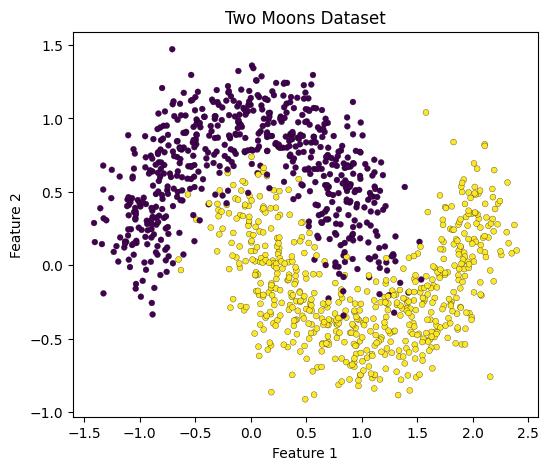

In [13]:

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=18, edgecolor="k", linewidth=0.2)
plt.title("Two Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### What are we looking at?

Each point has **two input features**: `(x1, x2)`.  
The label is either **0** or **1**.

This is a useful learning dataset because:

- the classes are **not linearly separable**,
- so a simple straight-line boundary is not enough,
- which motivates using **hidden layers + nonlinear activation functions**.

That is exactly where neural networks become interesting.


## 7. Train / Validation / Test Split and Scaling

We split the data into three parts:

- **training set**: used to update model weights,
- **validation set**: used to tune choices such as architecture or patience,
- **test set**: used only at the end for final evaluation.

We also scale the features. Neural networks often train more smoothly when input features are on comparable numeric scales.

### Common scaling choices

| Option | Meaning | Typical effect |
|---|---|---|
| No scaling | use raw features | may still work on simple data, but training can be less stable |
| `StandardScaler` | center to mean 0 and std 1 | strong default for many neural-network inputs |
| `MinMaxScaler` | map to a fixed range such as 0 to 1 | useful in some pipelines, especially when bounded inputs matter |

In this notebook we use **StandardScaler** as the main path, then briefly compare it with other options.


In [14]:

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.1765,
    random_state=SEED,
    stratify=y_train_full,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape, y_train.shape)
print("Validation:", X_val_scaled.shape, y_val.shape)
print("Test:", X_test_scaled.shape, y_test.shape)

Train: (839, 2) (839,)
Validation: (181, 2) (181,)
Test: (180, 2) (180,)


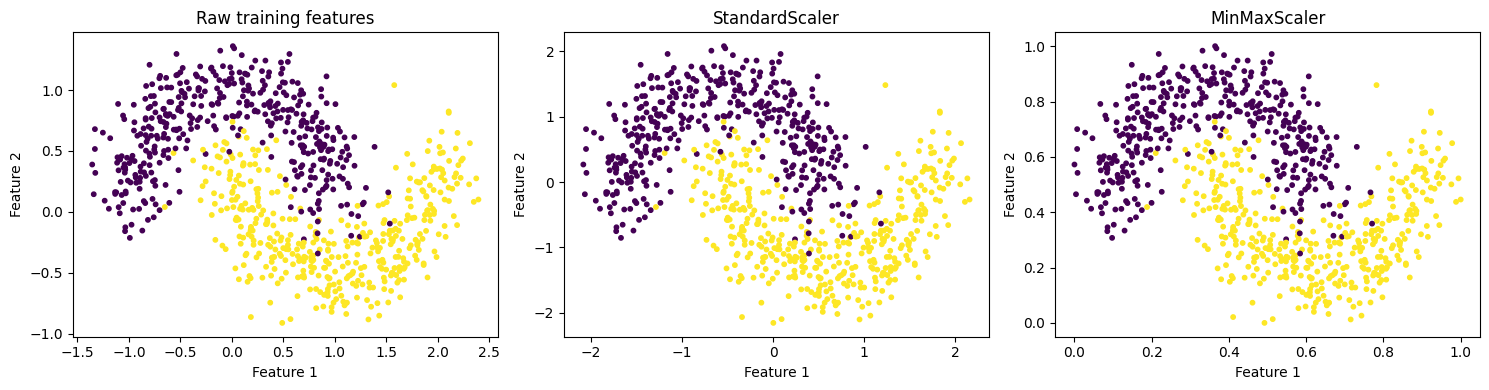

In [45]:

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

X_train_std = standard_scaler.fit_transform(X_train)
X_train_mm = minmax_scaler.fit_transform(X_train)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=10)
axes[0].set_title("Raw training features")
axes[1].scatter(X_train_std[:, 0], X_train_std[:, 1], c=y_train, s=10)
axes[1].set_title("StandardScaler")
axes[2].scatter(X_train_mm[:, 0], X_train_mm[:, 1], c=y_train, s=10)
axes[2].set_title("MinMaxScaler")
for ax in axes:
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
plt.tight_layout()
plt.show()

### Keras vs. PyTorch note for this part

- **The data split and feature scaling logic is the same** before it reaches either framework.
- The biggest difference appears later in the training loop, not in the preprocessing itself.
- In real projects, both frameworks often rely on the same surrounding Python ecosystem: NumPy, pandas, scikit-learn, matplotlib, and Jupyter.


## 8. First Side-by-Side Look at the Same Model

Before we automate experiments, it helps to see the same model idea written once in each framework.

We will use a simple multilayer perceptron with:

- input size = **2**
- one hidden layer
- one output unit for binary classification

We start with **ReLU** in the hidden layer because it is a very common default.


In [16]:

if TF_AVAILABLE:
    keras_demo_model = keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.0),
        layers.Dense(1, activation="sigmoid")
    ])

    print("Keras model summary:")
    keras_demo_model.summary()
else:
    print("TensorFlow/Keras is not installed in this environment.")

Keras model summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:

if TORCH_AVAILABLE:
    class TorchDemoMLP(nn.Module):
        def __init__(self, hidden_units=16, dropout_rate=0.0):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(2, hidden_units),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(hidden_units, 1)
            )

        def forward(self, x):
            return self.net(x)

    torch_demo_model = TorchDemoMLP(hidden_units=16, dropout_rate=0.0)
    print(torch_demo_model)
else:
    print("PyTorch is not installed in this environment.")

TorchDemoMLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=16, out_features=1, bias=True)
  )
)


### What you should notice immediately

#### Keras / TensorFlow feel
- You often define the network compactly with `Sequential`.
- Training can later be done with `model.compile(...)` and `model.fit(...)`.
- This style is concise and beginner-friendly.

#### PyTorch feel
- You usually define a custom class that inherits from `nn.Module`.
- The forward pass is explicit.
- You usually write the training loop yourself.

### Binary classification output: one subtle but important difference

In this notebook:

- the **Keras** model uses **`sigmoid` in the output layer** and **binary cross-entropy**,
- the **PyTorch** model returns **raw logits** and uses **`BCEWithLogitsLoss`** during training.

These are closely related ideas.  
`BCEWithLogitsLoss` combines the sigmoid operation and binary cross-entropy in a numerically stable way.


## 9. Activation Functions: Meaning, Options, and Effects

Activation functions are one of the first places where a neural network becomes **nonlinear**.

Without a nonlinear activation, stacking dense layers would still behave like a linear model.

### Common activation choices

| Activation | Meaning | Strengths | Weaknesses | Typical use |
|---|---|---|---|---|
| `relu` | `max(0, x)` | simple, fast, strong default | neurons can "die" if they never activate | hidden layers |
| `tanh` | squashes output to `[-1, 1]` | centered around zero, historically important | can saturate and slow gradients | some smaller MLPs, recurrent settings |
| `sigmoid` | squashes output to `[0, 1]` | interpretable as probability | saturates easily in hidden layers | output layer for binary probability |
| `leaky_relu` | ReLU with a small negative slope | reduces dead-neuron problem | one more hyperparameter / design choice | hidden layers |

### Practical rule of thumb

- Start with **ReLU** for hidden layers.
- Try **tanh** when you want to compare behavior and training smoothness.
- Avoid **sigmoid in hidden layers** unless you have a specific reason.
- Keep **sigmoid mainly for binary output probabilities**.


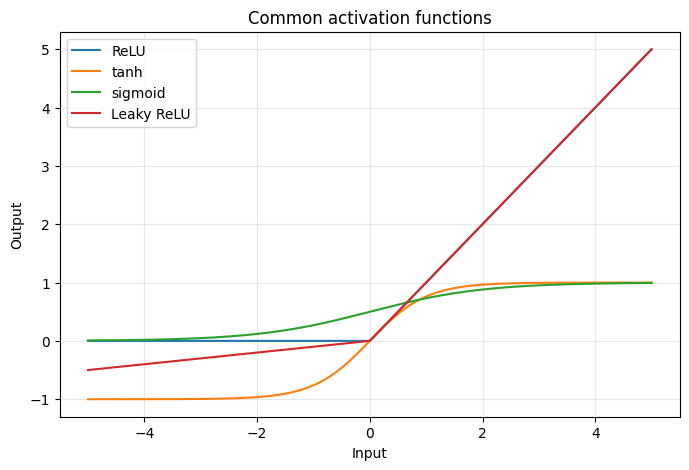

In [18]:

def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def leaky_relu(x, alpha=0.1):
    return np.where(x > 0, x, alpha * x)

x_vals = np.linspace(-5, 5, 400)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, relu(x_vals), label="ReLU")
plt.plot(x_vals, tanh(x_vals), label="tanh")
plt.plot(x_vals, sigmoid(x_vals), label="sigmoid")
plt.plot(x_vals, leaky_relu(x_vals), label="Leaky ReLU")
plt.title("Common activation functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### What differences do these make in practice?

- **ReLU** often trains quickly and is the default choice for many feed-forward networks.
- **tanh** can work well on small problems and sometimes gives smoother decision boundaries.
- **sigmoid** hidden layers can make training slower because gradients can shrink too much.
- **Leaky ReLU** is often a safer version of ReLU when you worry about inactive units.

### Keras vs. PyTorch note for this part

- In **Keras**, you can often specify an activation directly inside a layer, such as `Dense(16, activation="relu")`.
- In **PyTorch**, you usually place the activation as a separate module such as `nn.ReLU()` inside `nn.Sequential` or in `forward()`.
- Same math, different style.


In [19]:

def make_activation_name(name):
    name = name.lower()
    valid = {"relu", "tanh", "sigmoid", "leaky_relu"}
    if name not in valid:
        raise ValueError(f"Unsupported activation: {name}")
    return name

def keras_hidden_block(hidden_units, activation, dropout_rate):
    activation = make_activation_name(activation)
    block = [layers.Input(shape=(2,))]
    if activation == "leaky_relu":
        block.append(layers.Dense(hidden_units))
        block.append(layers.LeakyReLU())
    else:
        block.append(layers.Dense(hidden_units, activation=activation))
    if dropout_rate > 0:
        block.append(layers.Dropout(dropout_rate))
    block.append(layers.Dense(1, activation="sigmoid"))
    return block

def build_keras_model(hidden_units=16, activation="relu", optimizer_name="adam",
                      learning_rate=1e-3, dropout_rate=0.0):
    if not TF_AVAILABLE:
        raise RuntimeError("TensorFlow/Keras is not available.")

    optimizer_name = optimizer_name.lower()
    optimizer_map = {
        "adam": keras.optimizers.Adam,
        "sgd": keras.optimizers.SGD,
        "rmsprop": keras.optimizers.RMSprop,
    }
    if optimizer_name not in optimizer_map:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    model = keras.Sequential(keras_hidden_block(hidden_units, activation, dropout_rate))
    optimizer = optimizer_map[optimizer_name](learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
    return model

if TORCH_AVAILABLE:
    class TorchMLP(nn.Module):
        def __init__(self, hidden_units=16, activation="relu", dropout_rate=0.0):
            super().__init__()
            activation = make_activation_name(activation)
            activation_map = {
                "relu": nn.ReLU(),
                "tanh": nn.Tanh(),
                "sigmoid": nn.Sigmoid(),
                "leaky_relu": nn.LeakyReLU(),
            }
            modules = [
                nn.Linear(2, hidden_units),
                activation_map[activation],
            ]
            if dropout_rate > 0:
                modules.append(nn.Dropout(dropout_rate))
            modules.append(nn.Linear(hidden_units, 1))
            self.net = nn.Sequential(*modules)

        def forward(self, x):
            return self.net(x)

## 10. Training Hyperparameters: What They Mean and What They Affect

This is one of the most important parts of the notebook.

### 1. Hidden units
The number of neurons in a hidden layer controls the model's **capacity**.

- **Too few units** → the model may be too simple and underfit.
- **Too many units** → the model can fit complex patterns, but may overfit and train more slowly.

For this toy problem:

- 4 units may be too limited,
- 16 or 32 often works well,
- 128 may be excessive.

### 2. Learning rate
The learning rate controls the **step size** during optimization.

- **Too small** → training is slow and may stall.
- **Too large** → training can become unstable or bounce around the minimum.

### 3. Batch size
Batch size is the number of samples used before one gradient update.

- **Small batch size** → noisier gradients, sometimes better generalization
- **Large batch size** → smoother gradients, better hardware utilization, may require learning-rate tuning

### 4. Epochs
One epoch means the model has seen the full training set once.

- **Too few epochs** → undertraining
- **Too many epochs** → risk of overfitting

That is why we often use **early stopping** instead of choosing a perfect epoch count manually.

### 5. Dropout
Dropout randomly turns off a fraction of units during training.

- helps regularize the model,
- can reduce overfitting,
- but too much dropout may hurt learning.

### 6. Optimizer
The optimizer decides **how gradients are turned into parameter updates**.

Common options we compare in this notebook:

- **SGD**: simple, classic, educational, may need more tuning
- **Adam**: adaptive, widely used default
- **RMSprop**: adaptive and often stable on smaller problems

### Keras vs. PyTorch note for this part

The hyperparameters themselves mean the **same thing** in both frameworks.  
The difference is mostly in **how explicitly you control them**:

- **Keras** exposes many of them directly in `compile()` and `fit()`.
- **PyTorch** makes you write more of the training behavior yourself, which is useful for learning.


In [20]:

def plot_training_curves(history_dict, title_prefix="Training"):
    df = pd.DataFrame(history_dict)
    df["epoch"] = np.arange(1, len(df) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(df["epoch"], df["train_loss"], label="Train loss")
    axes[0].plot(df["epoch"], df["val_loss"], label="Val loss")
    axes[0].set_title(f"{title_prefix}: loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(df["epoch"], df["train_accuracy"], label="Train accuracy")
    axes[1].plot(df["epoch"], df["val_accuracy"], label="Val accuracy")
    axes[1].set_title(f"{title_prefix}: accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def plot_decision_boundary(predict_fn, X_plot, y_plot, title="Decision boundary", levels=30):
    x_min, x_max = X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5
    y_min, y_max = X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = predict_fn(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    contour = plt.contourf(xx, yy, probs, levels=levels, alpha=0.8)
    plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, s=18, edgecolor="k", linewidth=0.2)
    plt.colorbar(contour, label="Predicted probability of class 1")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

def train_keras_model(hidden_units=16, activation="relu", optimizer_name="adam",
                      learning_rate=1e-3, batch_size=32, dropout_rate=0.0,
                      max_epochs=80, patience=10, verbose=0):
    if not TF_AVAILABLE:
        raise RuntimeError("TensorFlow/Keras is not available.")

    model = build_keras_model(
        hidden_units=hidden_units,
        activation=activation,
        optimizer_name=optimizer_name,
        learning_rate=learning_rate,
        dropout_rate=dropout_rate,
    )

    callback = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=max_epochs,
        batch_size=batch_size,
        verbose=verbose,
        callbacks=[callback],
    )

    val_loss, val_acc = model.evaluate(X_val_scaled, y_val, verbose=0)
    test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)

    history_dict = {
        "train_loss": history.history["loss"],
        "val_loss": history.history["val_loss"],
        "train_accuracy": history.history["accuracy"],
        "val_accuracy": history.history["val_accuracy"],
    }

    return {
        "framework": "Keras",
        "model": model,
        "history": history_dict,
        "epochs_run": len(history_dict["train_loss"]),
        "val_loss": float(val_loss),
        "val_accuracy": float(val_acc),
        "test_loss": float(test_loss),
        "test_accuracy": float(test_acc),
        "predict_fn": lambda X_new: model.predict(np.asarray(X_new), verbose=0).ravel(),
    }

def train_torch_model(hidden_units=16, activation="relu", optimizer_name="adam",
                      learning_rate=1e-3, batch_size=32, dropout_rate=0.0,
                      max_epochs=80, patience=10, verbose=0):
    if not TORCH_AVAILABLE:
        raise RuntimeError("PyTorch is not available.")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_train_t = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
    X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
    y_val_t = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_test_t = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)

    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size,
        shuffle=True,
    )

    model = TorchMLP(hidden_units=hidden_units, activation=activation, dropout_rate=dropout_rate).to(device)

    optimizer_name = optimizer_name.lower()
    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    elif optimizer_name == "rmsprop":
        optimizer = torch.optim.RMSprop(model.parameters(), lr=learning_rate)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    criterion = nn.BCEWithLogitsLoss()

    train_loss_hist, val_loss_hist = [], []
    train_acc_hist, val_acc_hist = [], []

    best_state = None
    best_val_loss = float("inf")
    epochs_without_improvement = 0

    for epoch in range(max_epochs):
        model.train()
        batch_losses = []
        batch_correct = 0
        batch_total = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())
            preds = (torch.sigmoid(logits) >= 0.5).float()
            batch_correct += (preds == yb).sum().item()
            batch_total += yb.numel()

        model.eval()
        with torch.no_grad():
            train_loss = float(np.mean(batch_losses))
            train_acc = batch_correct / batch_total

            val_logits = model(X_val_t.to(device))
            val_loss = criterion(val_logits, y_val_t.to(device)).item()
            val_preds = (torch.sigmoid(val_logits) >= 0.5).float()
            val_acc = (val_preds == y_val_t.to(device)).float().mean().item()

        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)
        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

        if epochs_without_improvement >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t.to(device))
        test_logits = model(X_test_t.to(device))
        val_loss = criterion(val_logits, y_val_t.to(device)).item()
        test_loss = criterion(test_logits, y_test_t.to(device)).item()
        val_probs = torch.sigmoid(val_logits).cpu().numpy().ravel()
        test_probs = torch.sigmoid(test_logits).cpu().numpy().ravel()

    val_preds = (val_probs >= 0.5).astype(int)
    test_preds = (test_probs >= 0.5).astype(int)

    history_dict = {
        "train_loss": train_loss_hist,
        "val_loss": val_loss_hist,
        "train_accuracy": train_acc_hist,
        "val_accuracy": val_acc_hist,
    }

    def predict_fn(X_new):
        model.eval()
        X_new = np.asarray(X_new, dtype=np.float32)
        with torch.no_grad():
            X_new_t = torch.tensor(X_new, dtype=torch.float32).to(device)
            probs = torch.sigmoid(model(X_new_t)).cpu().numpy().ravel()
        return probs

    return {
        "framework": "PyTorch",
        "model": model,
        "history": history_dict,
        "epochs_run": len(history_dict["train_loss"]),
        "val_loss": float(val_loss),
        "val_accuracy": float(accuracy_score(y_val, val_preds)),
        "test_loss": float(test_loss),
        "test_accuracy": float(accuracy_score(y_test, test_preds)),
        "predict_fn": predict_fn,
    }

def compare_parameter(parameter_name, values, framework_kwargs=None, fixed_kwargs=None):
    framework_kwargs = framework_kwargs or ["keras", "torch"]
    fixed_kwargs = fixed_kwargs or {}

    rows = []

    for value in values:
        kwargs = dict(fixed_kwargs)
        kwargs[parameter_name] = value

        if "keras" in framework_kwargs and TF_AVAILABLE:
            result = train_keras_model(**kwargs)
            rows.append({
                "framework": "Keras",
                parameter_name: value,
                "epochs_run": result["epochs_run"],
                "val_accuracy": result["val_accuracy"],
                "test_accuracy": result["test_accuracy"],
            })

        if "torch" in framework_kwargs and TORCH_AVAILABLE:
            result = train_torch_model(**kwargs)
            rows.append({
                "framework": "PyTorch",
                parameter_name: value,
                "epochs_run": result["epochs_run"],
                "val_accuracy": result["val_accuracy"],
                "test_accuracy": result["test_accuracy"],
            })

    return pd.DataFrame(rows)

def plot_experiment_results(df, x_col, title):
    if df.empty:
        print("No results to plot.")
        return

    frameworks = df["framework"].unique()
    x_positions = np.arange(len(df[x_col].astype(str).unique()))
    unique_values = list(df[x_col].astype(str).unique())
    width = 0.35 if len(frameworks) > 1 else 0.6

    plt.figure(figsize=(8, 4))
    for i, framework in enumerate(frameworks):
        subset = df[df["framework"] == framework].copy()
        subset[x_col] = subset[x_col].astype(str)
        subset = subset.set_index(x_col).reindex(unique_values).reset_index()
        offset = (i - (len(frameworks) - 1) / 2) * width
        plt.bar(x_positions + offset, subset["val_accuracy"], width=width, label=framework)

    plt.xticks(x_positions, unique_values)
    plt.ylim(0.0, 1.0)
    plt.xlabel(x_col)
    plt.ylabel("Validation accuracy")
    plt.title(title)
    plt.legend()
    plt.show()

## 11. Baseline Training: Same Problem, Two Framework Styles

We now train the **same basic model idea** in both frameworks.

### Baseline choices

- hidden units = **16**
- activation = **ReLU**
- optimizer = **Adam**
- learning rate = **0.001**
- batch size = **32**
- dropout = **0.0**
- early stopping patience = **10**

These are not magical values. They are just sensible starting defaults for a small MLP on a simple binary task.


In [21]:

baseline_keras = None
baseline_torch = None

if TF_AVAILABLE:
    baseline_keras = train_keras_model(
        hidden_units=16,
        activation="relu",
        optimizer_name="adam",
        learning_rate=1e-3,
        batch_size=32,
        dropout_rate=0.0,
        max_epochs=80,
        patience=10,
        verbose=0,
    )
    print("Keras baseline test accuracy:", round(baseline_keras["test_accuracy"], 4))
else:
    print("Skipping Keras baseline because TensorFlow is unavailable.")

if TORCH_AVAILABLE:
    baseline_torch = train_torch_model(
        hidden_units=16,
        activation="relu",
        optimizer_name="adam",
        learning_rate=1e-3,
        batch_size=32,
        dropout_rate=0.0,
        max_epochs=80,
        patience=10,
        verbose=0,
    )
    print("PyTorch baseline test accuracy:", round(baseline_torch["test_accuracy"], 4))
else:
    print("Skipping PyTorch baseline because PyTorch is unavailable.")

Keras baseline test accuracy: 0.9222
PyTorch baseline test accuracy: 0.9333


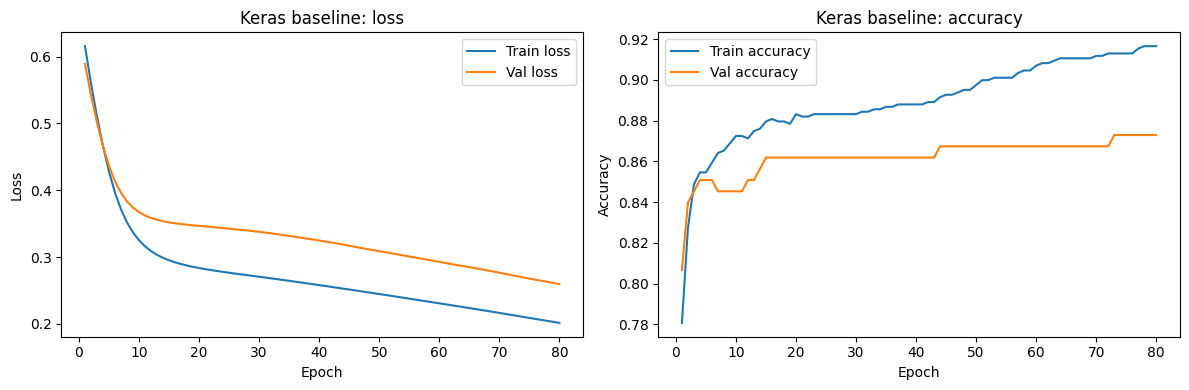

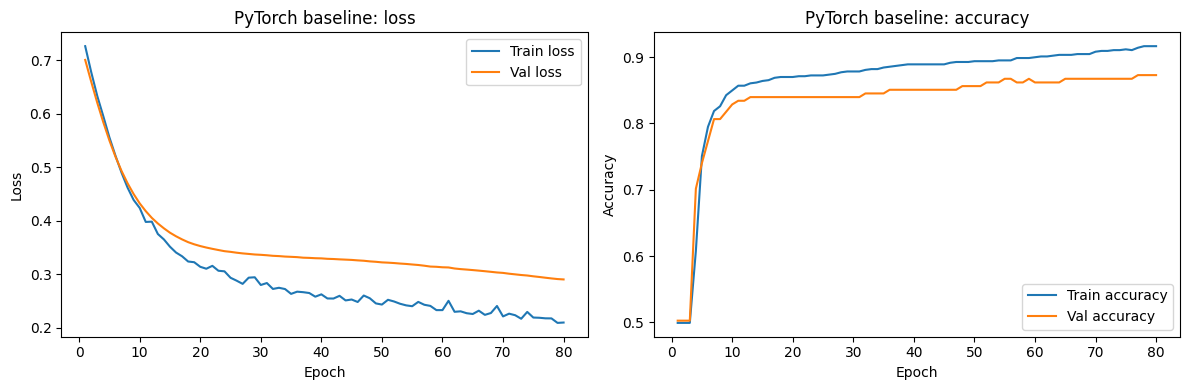

In [22]:

if baseline_keras is not None:
    plot_training_curves(baseline_keras["history"], title_prefix="Keras baseline")

if baseline_torch is not None:
    plot_training_curves(baseline_torch["history"], title_prefix="PyTorch baseline")

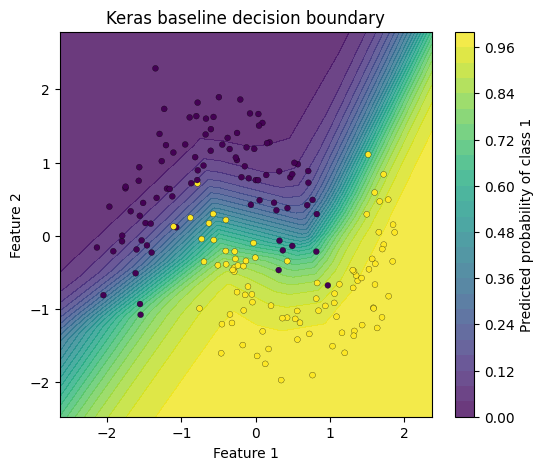

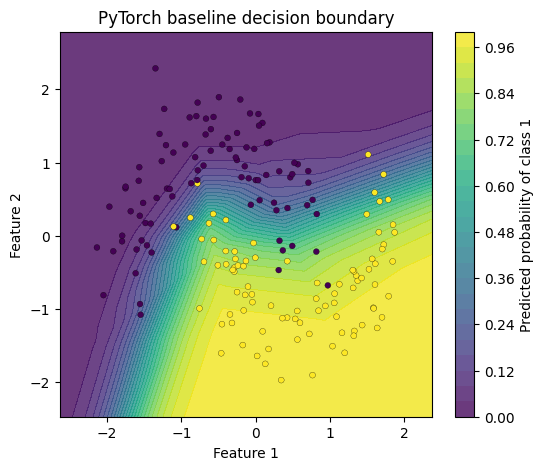

In [23]:

if baseline_keras is not None:
    plot_decision_boundary(
        baseline_keras["predict_fn"],
        X_test_scaled,
        y_test,
        title="Keras baseline decision boundary"
    )

if baseline_torch is not None:
    plot_decision_boundary(
        baseline_torch["predict_fn"],
        X_test_scaled,
        y_test,
        title="PyTorch baseline decision boundary"
    )

### Keras vs. PyTorch note for this part

- **Keras** gets you to a working baseline with very little code.
- **PyTorch** exposes the mechanics more clearly: data loader, forward pass, loss, backward pass, optimizer step.
- You often understand optimization better after seeing the PyTorch loop, then appreciate Keras more for how much it automates.


## 12. Activation Function Comparison

We now compare **three common hidden-layer activations**:

- `relu`
- `tanh`
- `sigmoid`

We keep the rest of the hyperparameters fixed so that the activation choice is the main thing changing.


In [24]:

activation_results = compare_parameter(
    parameter_name="activation",
    values=["relu", "tanh", "sigmoid"],
    fixed_kwargs={
        "hidden_units": 16,
        "optimizer_name": "adam",
        "learning_rate": 1e-3,
        "batch_size": 32,
        "dropout_rate": 0.0,
        "max_epochs": 80,
        "patience": 10,
        "verbose": 0,
    },
)
activation_results

,framework,activation,epochs_run,val_accuracy,test_accuracy
0,Keras,relu,80,0.895028,0.955556
1,PyTorch,relu,80,0.861878,0.922222
2,Keras,tanh,80,0.872928,0.916667
3,PyTorch,tanh,80,0.867403,0.911111
4,Keras,sigmoid,61,0.850829,0.894444
5,PyTorch,sigmoid,69,0.850829,0.894444


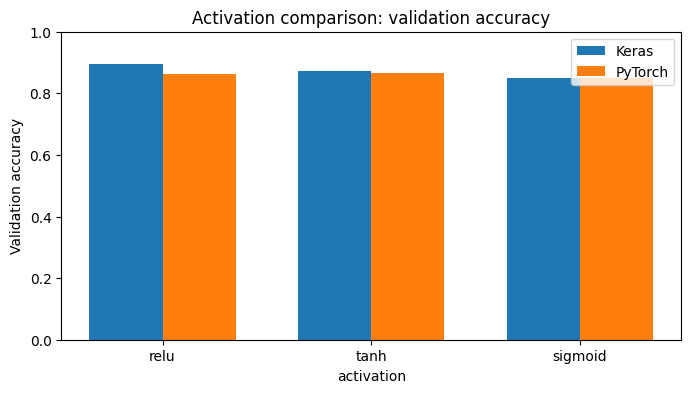

In [25]:

plot_experiment_results(
    activation_results,
    x_col="activation",
    title="Activation comparison: validation accuracy"
)

### How to interpret the activation results

Questions to ask:

1. Which activation reached the best validation accuracy?
2. Which one converged in fewer epochs?
3. Which activation seems easiest to train on this small problem?

Typical pattern on small MLPs:

- **ReLU** is often a strong default.
- **tanh** can be competitive.
- **sigmoid** in hidden layers often underperforms because gradients can shrink too much.

### Keras vs. PyTorch note for this part

The activation comparison is conceptually the same in both frameworks.  
The visible difference is mostly syntax:

- **Keras**: activations are often specified inside the layer.
- **PyTorch**: activations are often separate modules placed between layers.


## 13. Optimizer Comparison

Now we compare **SGD**, **Adam**, and **RMSprop**.

### What these optimizers mean in practice

- **SGD**  
  The classic optimizer. It is simple and educational, but often needs more tuning.

- **Adam**  
  A very common default. It adapts learning rates for parameters and usually works well quickly.

- **RMSprop**  
  Another adaptive optimizer that often behaves smoothly on smaller tasks.

There is no universal winner.  
The best choice depends on the model, data, regularization, learning rate, and training budget.


In [26]:

optimizer_results = compare_parameter(
    parameter_name="optimizer_name",
    values=["sgd", "adam", "rmsprop"],
    fixed_kwargs={
        "hidden_units": 16,
        "activation": "relu",
        "learning_rate": 1e-3,
        "batch_size": 32,
        "dropout_rate": 0.0,
        "max_epochs": 80,
        "patience": 10,
        "verbose": 0,
    },
)
optimizer_results

,framework,optimizer_name,epochs_run,val_accuracy,test_accuracy
0,Keras,sgd,80,0.723757,0.777778
1,PyTorch,sgd,80,0.790055,0.805556
2,Keras,adam,80,0.867403,0.927778
3,PyTorch,adam,80,0.872928,0.905556
4,Keras,rmsprop,80,0.872928,0.938889
5,PyTorch,rmsprop,80,0.867403,0.922222


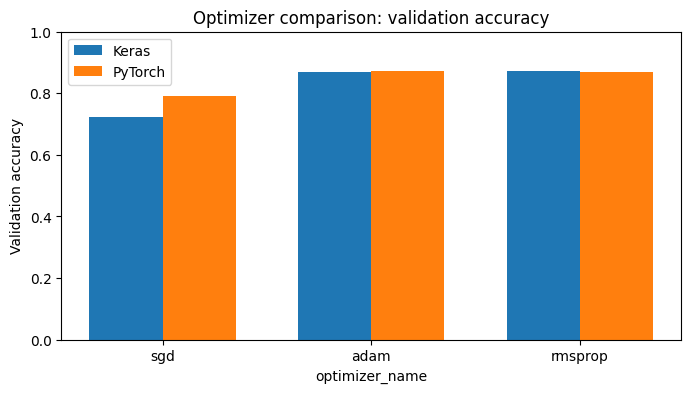

In [27]:

plot_experiment_results(
    optimizer_results,
    x_col="optimizer_name",
    title="Optimizer comparison: validation accuracy"
)

### How to interpret the optimizer results

Look for:

- which optimizer reached strong validation accuracy,
- whether one optimizer converged in fewer epochs,
- and whether one seemed noticeably unstable or slow.

A common beginner outcome is:

- **Adam** gives a strong baseline quickly,
- **SGD** may need either more epochs or a different learning rate,
- **RMSprop** can land somewhere between them depending on the task.

### Keras vs. PyTorch note for this part

- In **Keras**, you choose the optimizer in `compile()`.
- In **PyTorch**, you instantiate it directly from `torch.optim` and connect it to model parameters.
- PyTorch makes the optimizer-step mechanics more visible, which is useful for learning.


## 14. Learning Rate Comparison

The learning rate is one of the most influential hyperparameters.

We compare:

- `1e-4`
- `1e-3`
- `1e-2`

### Expected behavior

- **Too small** → slow learning
- **About right** → steady improvement
- **Too large** → unstable training or overshooting


In [28]:

learning_rate_results = compare_parameter(
    parameter_name="learning_rate",
    values=[1e-4, 1e-3, 1e-2],
    fixed_kwargs={
        "hidden_units": 16,
        "activation": "relu",
        "optimizer_name": "adam",
        "batch_size": 32,
        "dropout_rate": 0.0,
        "max_epochs": 80,
        "patience": 10,
        "verbose": 0,
    },
)
learning_rate_results

,framework,learning_rate,epochs_run,val_accuracy,test_accuracy
0,Keras,0.0001,80,0.828729,0.872222
1,PyTorch,0.0001,80,0.834254,0.838889
2,Keras,0.0010,80,0.895028,0.961111
3,PyTorch,0.0010,80,0.878453,0.922222
4,Keras,0.0100,41,0.950276,0.972222
5,PyTorch,0.0100,52,0.961326,0.977778


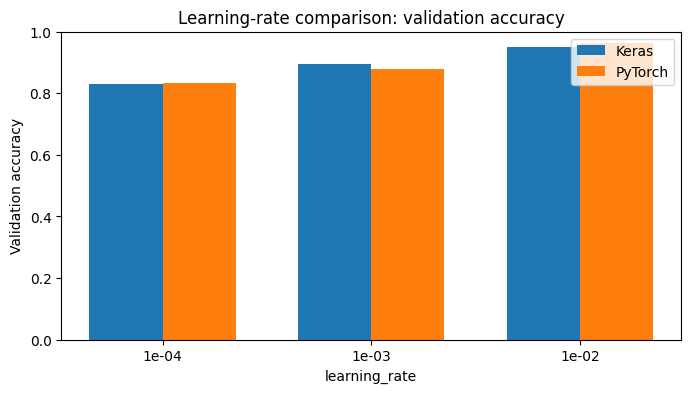

In [29]:

plot_experiment_results(
    learning_rate_results.assign(learning_rate=learning_rate_results["learning_rate"].map(lambda v: f"{v:.0e}")),
    x_col="learning_rate",
    title="Learning-rate comparison: validation accuracy"
)

### How to interpret the learning-rate results

Useful questions:

1. Did the smallest learning rate train too slowly?
2. Did the largest learning rate become unstable?
3. Which value gave the best balance between speed and accuracy?

### Keras vs. PyTorch note for this part

The learning rate means the same thing mathematically in both frameworks.  
But because **PyTorch shows the training loop explicitly**, it often helps you understand *where* the learning rate actually influences updates.


## 15. Batch Size Comparison

We compare three batch sizes:

- `16`
- `32`
- `128`

### What changes when batch size changes?

- how noisy the gradient estimate is,
- how often parameter updates happen per epoch,
- how much memory the batch uses,
- and sometimes how well the model generalizes.


In [30]:

batch_size_results = compare_parameter(
    parameter_name="batch_size",
    values=[16, 32, 128],
    fixed_kwargs={
        "hidden_units": 16,
        "activation": "relu",
        "optimizer_name": "adam",
        "learning_rate": 1e-3,
        "dropout_rate": 0.0,
        "max_epochs": 80,
        "patience": 10,
        "verbose": 0,
    },
)
batch_size_results

,framework,batch_size,epochs_run,val_accuracy,test_accuracy
0,Keras,16,80,0.911602,0.966667
1,PyTorch,16,80,0.928177,0.966667
2,Keras,32,80,0.883978,0.955556
3,PyTorch,32,80,0.878453,0.933333
4,Keras,128,80,0.856354,0.900000
5,PyTorch,128,80,0.856354,0.900000


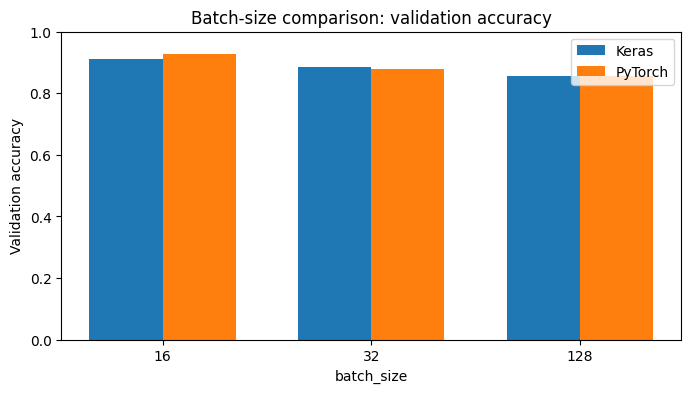

In [31]:

plot_experiment_results(
    batch_size_results.assign(batch_size=batch_size_results["batch_size"].astype(str)),
    x_col="batch_size",
    title="Batch-size comparison: validation accuracy"
)

### How to interpret the batch-size results

- **Smaller batch sizes** often add noise that can help escape poor local behavior.
- **Larger batch sizes** may be computationally efficient but can sometimes need a different learning rate.
- For small problems like this one, the differences may be modest, which is itself an important lesson.

### Keras vs. PyTorch note for this part

- In **Keras**, batch size is passed to `fit()`.
- In **PyTorch**, batch size is set in the `DataLoader`.
- PyTorch makes it easier to see that batch size belongs to the **data pipeline**, not the model definition itself.


## 16. Dropout Comparison

Dropout is a regularization method.  
It randomly removes a fraction of hidden activations during training.

We compare:

- `0.0`
- `0.2`
- `0.5`

### Expected trade-offs

- **0.0**: no regularization from dropout
- **0.2**: light regularization
- **0.5**: strong regularization, sometimes too strong for a small model


In [32]:

dropout_results = compare_parameter(
    parameter_name="dropout_rate",
    values=[0.0, 0.2, 0.5],
    fixed_kwargs={
        "hidden_units": 32,
        "activation": "relu",
        "optimizer_name": "adam",
        "learning_rate": 1e-3,
        "batch_size": 32,
        "max_epochs": 80,
        "patience": 10,
        "verbose": 0,
    },
)
dropout_results

,framework,dropout_rate,epochs_run,val_accuracy,test_accuracy
0,Keras,0.0,80,0.911602,0.966667
1,PyTorch,0.0,80,0.917127,0.961111
2,Keras,0.2,80,0.889503,0.955556
3,PyTorch,0.2,80,0.895028,0.961111
4,Keras,0.5,80,0.878453,0.933333
5,PyTorch,0.5,80,0.872928,0.938889


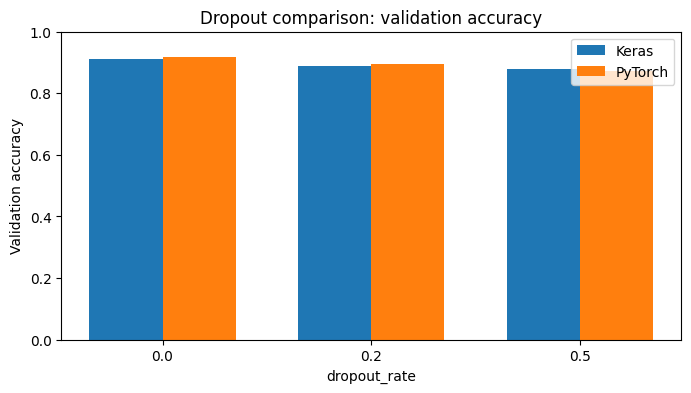

In [33]:

plot_experiment_results(
    dropout_results.assign(dropout_rate=dropout_results["dropout_rate"].astype(str)),
    x_col="dropout_rate",
    title="Dropout comparison: validation accuracy"
)

### How to interpret the dropout results

Questions to ask:

1. Does a little dropout help validation accuracy?
2. Does too much dropout make the model underfit?
3. On such a small dataset, is dropout helping or just making learning harder?

### Keras vs. PyTorch note for this part

The regularization idea is identical in both frameworks.  
The difference is mostly stylistic:

- **Keras**: `layers.Dropout(rate)`
- **PyTorch**: `nn.Dropout(p)`


## 17. Hidden-Unit Comparison

Now we compare model capacity more directly.

We test:

- `4`
- `16`
- `64`

This helps us see **underfitting vs. sufficient capacity vs. possible overcapacity**.


In [34]:

hidden_unit_results = compare_parameter(
    parameter_name="hidden_units",
    values=[4, 16, 64],
    fixed_kwargs={
        "activation": "relu",
        "optimizer_name": "adam",
        "learning_rate": 1e-3,
        "batch_size": 32,
        "dropout_rate": 0.0,
        "max_epochs": 80,
        "patience": 10,
        "verbose": 0,
    },
)
hidden_unit_results

,framework,hidden_units,epochs_run,val_accuracy,test_accuracy
0,Keras,4,80,0.861878,0.900000
1,PyTorch,4,48,0.856354,0.894444
2,Keras,16,80,0.883978,0.955556
3,PyTorch,16,80,0.889503,0.938889
4,Keras,64,80,0.933702,0.972222
5,PyTorch,64,80,0.939227,0.972222


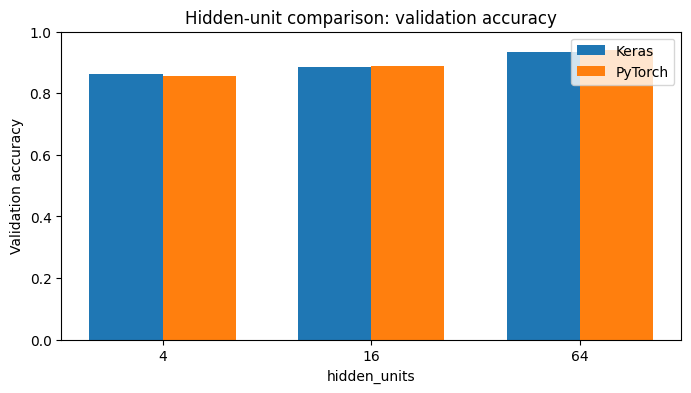

In [35]:

plot_experiment_results(
    hidden_unit_results.assign(hidden_units=hidden_unit_results["hidden_units"].astype(str)),
    x_col="hidden_units",
    title="Hidden-unit comparison: validation accuracy"
)

### How to interpret the hidden-unit results

- If **4 units** performs clearly worse, that is a sign of under-capacity.
- If **64 units** does not improve much, that tells you the simpler model may already be enough.
- If the bigger model helps, the task may need more expressive capacity.

### Keras vs. PyTorch note for this part

The architecture concept is identical.  
What differs is how much code you write to express the same idea.


## 18. A Compact Summary Table Across the Main Comparisons

This section combines all experiment tables into one view so you can see the main takeaways more easily.


In [36]:

summary_frames = []

for name, df in [
    ("activation", activation_results),
    ("optimizer", optimizer_results),
    ("learning_rate", learning_rate_results),
    ("batch_size", batch_size_results),
    ("dropout", dropout_results),
    ("hidden_units", hidden_unit_results),
]:
    temp = df.copy()
    temp["experiment"] = name
    summary_frames.append(temp)

experiment_summary = pd.concat(summary_frames, ignore_index=True)
experiment_summary.sort_values(["experiment", "framework", "val_accuracy"], ascending=[True, True, False]).head(30)

,framework,activation,epochs_run,val_accuracy,test_accuracy,experiment,optimizer_name,learning_rate,batch_size,dropout_rate,hidden_units
0,Keras,relu,80,0.895028,0.955556,activation,NaN,NaN,NaN,NaN,NaN
2,Keras,tanh,80,0.872928,0.916667,activation,NaN,NaN,NaN,NaN,NaN
4,Keras,sigmoid,61,0.850829,0.894444,activation,NaN,NaN,NaN,NaN,NaN
3,PyTorch,tanh,80,0.867403,0.911111,activation,NaN,NaN,NaN,NaN,NaN
1,PyTorch,relu,80,0.861878,0.922222,activation,NaN,NaN,NaN,NaN,NaN
5,PyTorch,sigmoid,69,0.850829,0.894444,activation,NaN,NaN,NaN,NaN,NaN
18,Keras,NaN,80,0.911602,0.966667,batch_size,NaN,NaN,16.0,NaN,NaN
20,Keras,NaN,80,0.883978,0.955556,batch_size,NaN,NaN,32.0,NaN,NaN
22,Keras,NaN,80,0.856354,0.900000,batch_size,NaN,NaN,128.0,NaN,NaN
19,PyTorch,NaN,80,0.928177,0.966667,batch_size,NaN,NaN,16.0,NaN,NaN


## 19. Complete Final Example: Side-by-Side Keras and PyTorch

Now we put everything together into a cleaner final configuration.

For a small problem like `make_moons`, a good default final model is often something like:

- hidden units = **32**
- activation = **ReLU**
- optimizer = **Adam**
- learning rate = **0.001**
- batch size = **32**
- dropout = **0.1**
- early stopping enabled

This is not guaranteed to be optimal.  
It is simply a balanced, practical configuration for a beginner-friendly tutorial.


In [37]:

final_config = {
    "hidden_units": 32,
    "activation": "relu",
    "optimizer_name": "adam",
    "learning_rate": 1e-3,
    "batch_size": 32,
    "dropout_rate": 0.1,
    "max_epochs": 120,
    "patience": 15,
    "verbose": 0,
}

final_keras = train_keras_model(**final_config) if TF_AVAILABLE else None
final_torch = train_torch_model(**final_config) if TORCH_AVAILABLE else None

if final_keras is not None:
    print("Final Keras test accuracy:", round(final_keras["test_accuracy"], 4))
if final_torch is not None:
    print("Final PyTorch test accuracy:", round(final_torch["test_accuracy"], 4))

Final Keras test accuracy: 0.9667
Final PyTorch test accuracy: 0.9667


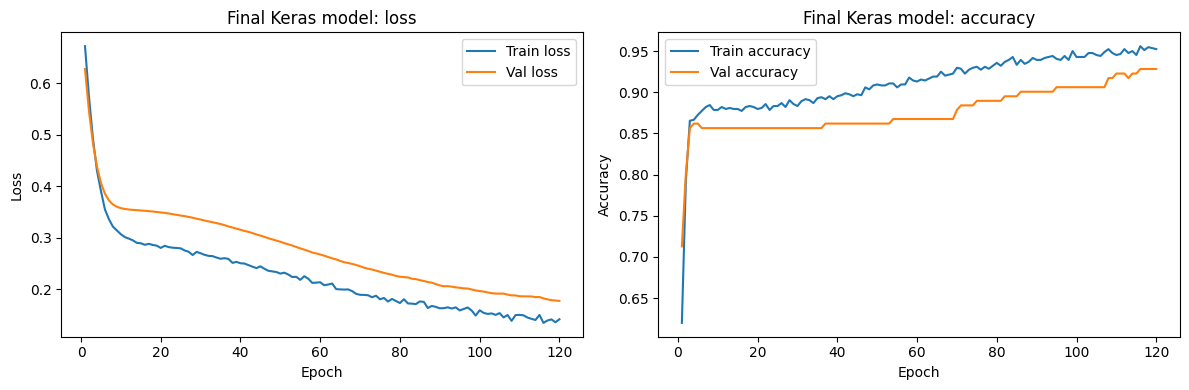

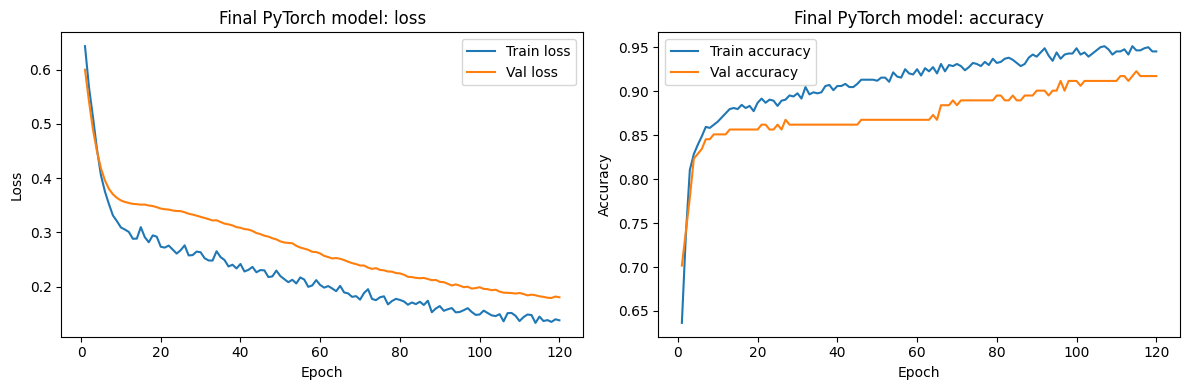

In [38]:

if final_keras is not None:
    plot_training_curves(final_keras["history"], title_prefix="Final Keras model")

if final_torch is not None:
    plot_training_curves(final_torch["history"], title_prefix="Final PyTorch model")

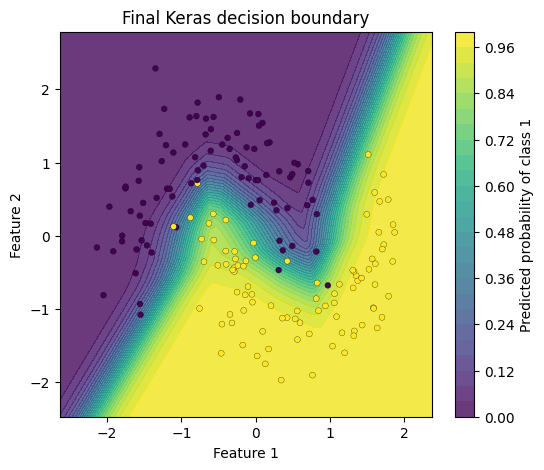

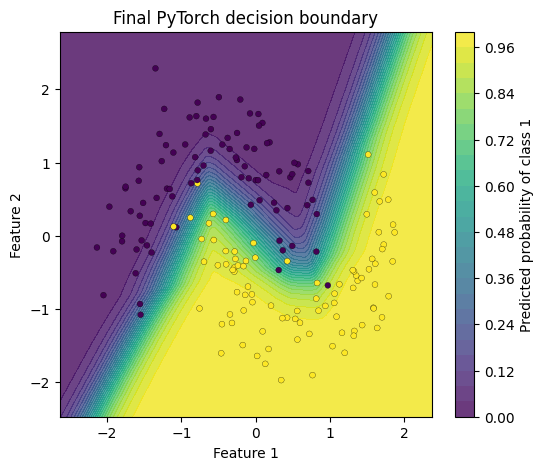

In [39]:

if final_keras is not None:
    plot_decision_boundary(
        final_keras["predict_fn"],
        X_test_scaled,
        y_test,
        title="Final Keras decision boundary"
    )

if final_torch is not None:
    plot_decision_boundary(
        final_torch["predict_fn"],
        X_test_scaled,
        y_test,
        title="Final PyTorch decision boundary"
    )

In [ ]:
if final_keras is not None:
    keras_test_probs = final_keras["predict_fn"](X_test_scaled)
    keras_test_preds = (keras_test_probs >= 0.5).astype(int)
    print("Keras classification report")
    print(classification_report(y_test, keras_test_preds))
    print("Keras confusion matrix")
    print(confusion_matrix(y_test, keras_test_preds))

if final_torch is not None:
    torch_test_probs = final_torch["predict_fn"](X_test_scaled)
    torch_test_preds = (torch_test_probs >= 0.5).astype(int)
    print("PyTorch classification report")
    print(classification_report(y_test, torch_test_preds))
    print("PyTorch confusion matrix")
    print(confusion_matrix(y_test, torch_test_preds))

Keras classification report
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        90
           1       0.98      0.96      0.97        90

    accuracy                           0.97       180
   macro avg       0.97      0.97      0.97       180
weighted avg       0.97      0.97      0.97       180

Keras confusion matrix
[[88  2]
 [ 4 86]]
PyTorch classification report
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        90
           1       0.98      0.96      0.97        90

    accuracy                           0.97       180
   macro avg       0.97      0.97      0.97       180
weighted avg       0.97      0.97      0.97       180

PyTorch confusion matrix
[[88  2]
 [ 4 86]]


In [41]:

sample_points_raw = np.array([
    [1.5, -0.2],
    [-0.5, 0.7],
    [0.3, 0.1],
], dtype=np.float32)

sample_points_scaled = scaler.transform(sample_points_raw)

if final_keras is not None:
    probs = final_keras["predict_fn"](sample_points_scaled)
    preds = (probs >= 0.5).astype(int)
    print("Keras sample predictions")
    for point, prob, pred in zip(sample_points_raw, probs, preds):
        print(f"point={point}, prob_class_1={prob:.4f}, predicted_class={pred}")

if final_torch is not None:
    probs = final_torch["predict_fn"](sample_points_scaled)
    preds = (probs >= 0.5).astype(int)
    print("\nPyTorch sample predictions")
    for point, prob, pred in zip(sample_points_raw, probs, preds):
        print(f"point={point}, prob_class_1={prob:.4f}, predicted_class={pred}")

Keras sample predictions
point=[ 1.5 -0.2], prob_class_1=0.9581, predicted_class=1
point=[-0.5  0.7], prob_class_1=0.0292, predicted_class=0
point=[0.3 0.1], prob_class_1=0.8192, predicted_class=1

PyTorch sample predictions
point=[ 1.5 -0.2], prob_class_1=0.9657, predicted_class=1
point=[-0.5  0.7], prob_class_1=0.0280, predicted_class=0
point=[0.3 0.1], prob_class_1=0.8443, predicted_class=1


### Keras vs. PyTorch note for the full workflow

#### Keras / TensorFlow
- shortest path from model idea to training result,
- very friendly for learning the big picture first,
- strong built-in callbacks and logging flow.

#### PyTorch
- clearer view of the optimization process,
- easier to customize step by step,
- especially helpful when you want to understand the mechanics behind `fit()`.

Seeing both is powerful because it separates:

- the **machine learning idea** (same),
- from the **framework style** (different).


## 20. What Changed from Raw Data to a Trained Model?

By this point, the workflow should feel more concrete:

1. **Create or load data**
2. **Visualize it**
3. **Split into train / validation / test**
4. **Scale features**
5. **Choose a model architecture**
6. **Choose activations, optimizer, batch size, learning rate, and dropout**
7. **Train while monitoring validation performance**
8. **Evaluate once on the test set**
9. **Visualize the learned decision boundary**
10. **Compare frameworks and reflect on trade-offs**

This is already a complete mini deep-learning project.


## 21. Documentation and Community: How to Use Them Well

A common beginner mistake is to search random blogs first.  
A better order is:

### Step 1: official documentation
Use official docs to verify:

- API signatures,
- parameter names,
- supported features,
- version-specific behavior.

### Step 2: official tutorials and guides
These are better than isolated snippets because they show the full workflow.

### Step 3: forums and Q&A
Use these when you hit a specific error, especially with the full error message and version numbers.

### Example of a strong troubleshooting query

Instead of searching:

> `tensorflow gpu problem`

search something like:

> `TensorFlow 2 GPU not detected Windows CUDA driver version`

The more precise the query, the better the answers.


## 22. Ethical Use of Generative AI During Setup and Learning

Generative AI can be very helpful for:

- explaining error messages,
- suggesting likely causes,
- generating starter code,
- translating documentation into simpler language.

But it should **not** replace understanding.

### Good use
- ask for an explanation of a stack trace,
- ask what a hyperparameter does,
- ask for a cleaner training loop,
- ask for a checklist to debug environment problems.

### Risky use
- copying environment files blindly,
- pasting generated code without testing,
- using a model-generated answer as the final authority over official docs,
- submitting generated work without understanding it.

### Best practice
Treat AI as a **learning assistant**, not as an unquestioned source of truth.

Always verify important setup advice with:

- official documentation,
- your actual package versions,
- and reproducible tests in your own environment.


## 23. Best Practices Checklist

Before you move to larger projects, make sure you can answer **yes** to most of these:

- [ ] I know which Python environment my notebook is using.
- [ ] I can print my TensorFlow or PyTorch version.
- [ ] I know whether I am training on CPU or GPU.
- [ ] I keep dependencies in `requirements.txt` or `environment.yml`.
- [ ] I use Git for version control.
- [ ] I keep training, validation, and test data separate.
- [ ] I can explain my main hyperparameters.
- [ ] I use official docs to confirm API behavior.


## 24. Suggested Exercises

1. Change `hidden_units` from `16` to `4`, `32`, and `128`.  
   What happens to the decision boundary and validation accuracy?

2. Try learning rates of `1e-4`, `1e-3`, and `1e-2`.  
   Which trains most reliably?

3. Increase the dataset noise in `make_moons`.  
   How does that change the benefit of dropout?

4. Add a second hidden layer in **both** frameworks.  
   Does it help on this problem, or is it unnecessary?

5. Add **Leaky ReLU** to the activation comparison and compare it against ReLU and tanh.

6. Re-implement early stopping manually in PyTorch if you skipped reading the loop closely the first time.


## 25. Key Takeaways

- Frameworks accelerate experimentation by giving you standard tools for model building, optimization, logging, and deployment.
- Keras/TensorFlow and PyTorch are both strong choices; the better framework depends on your workflow.
- Modern TensorFlow is **eager by default**, while still supporting graph compilation for performance.
- Hyperparameters are best understood as **trade-offs**, not magic values.
- A small end-to-end project is one of the best ways to learn framework concepts.
- Official documentation should be your first reference when behavior matters.
- Seeing the **same model in both frameworks** helps you separate concepts from syntax.


## 26. Where to Go Next

After this notebook, strong next topics are:

- deeper architectures,
- convolutional neural networks,
- regularization in more detail,
- custom training loops,
- mixed precision,
- distributed training,
- model serving and deployment.

### Recommended next reading

- TensorFlow tutorials: https://www.tensorflow.org/tutorials
- Keras guides: https://keras.io/guides/
- PyTorch tutorials: https://pytorch.org/tutorials/
- Deep Learning Book: https://www.deeplearningbook.org/
